In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Setting random seeds for reproducibility
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
train_df = pd.read_csv('data/train_processed.csv')
feature_cols = joblib.load('data/feature_columns.pkl')

In [4]:
def create_sequences(df, sequence_length=50):
    """
    Convert tabular data into sequences for Hybrid CNN-LSTM.
    """
    sequences = []
    targets = []

    # Group by engine
    for engine_id in df['unit_id'].unique():
        engine_data = df[df['unit_id'] == engine_id].sort_values('time_cycles')

        # Extract features and RUL
        features = engine_data[feature_cols].values
        rul = engine_data['RUL'].values

        # Create sequences
        for i in range(sequence_length, len(features)):
            # Take last 'sequence_length' timesteps
            seq = features[i-sequence_length:i]
            target = rul[i]

            sequences.append(seq)
            targets.append(target)

    return np.array(sequences), np.array(targets)

In [5]:
sequence_length = 50
print(f"\nCreating sequences with window size: {sequence_length} cycles")


Creating sequences with window size: 50 cycles


In [6]:
X, y = create_sequences(train_df, sequence_length)

In [7]:
print("\nSequence preparation completed!")

print(f"X shape : {X.shape}")   # (samples, timesteps, features)
print(f"y shape : {y.shape}")

print("\nDataset Breakdown:")
print(f"  • Total sequences        : {X.shape[0]:,}")
print(f"  • Timesteps in sequence  : {X.shape[1]}")
print(f"  • Features per timestep  : {X.shape[2]}")


Sequence preparation completed!
X shape : (15631, 50, 17)
y shape : (15631,)

Dataset Breakdown:
  • Total sequences        : 15,631
  • Timesteps in sequence  : 50
  • Features per timestep  : 17


In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# **Hybrid CNN-LSTM**

In [9]:
class CNNLSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        # CNN Feature Extraction Block
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.BatchNorm1d(64), nn.MaxPool1d(2), nn.Dropout(0.2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.BatchNorm1d(128), nn.Dropout(0.2)
        )

        # LSTM Temporal Learning Block
        self.lstm1   = nn.LSTM(128, 64, batch_first=True)
        self.drop1   = nn.Dropout(0.2)
        self.lstm2   = nn.LSTM(64, 32, batch_first=True)
        self.drop2   = nn.Dropout(0.2)

        # Dense Output Block
        self.fc = nn.Sequential(
            nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.cnn(x.permute(0, 2, 1))   # (batch, features, steps)
        x = x.permute(0, 2, 1)             # (batch, steps, features) for LSTM

        out, _ = self.lstm1(x)
        out    = self.drop1(out)
        out, _ = self.lstm2(out)
        out    = self.drop2(out[:, -1, :]) # last timestep

        return self.fc(out)

In [10]:
input_size = X.shape[2]
model = CNNLSTMModel(input_size=input_size)

print("\n Model Architecture:")
print(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


 Model Architecture:
CNNLSTMModel(
  (cnn): Sequential(
    (0): Conv1d(17, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): ReLU()
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Dropout(p=0.2, inplace=False)
  )
  (lstm1): LSTM(128, 64, batch_first=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total params:     91,713
Trainable params: 91,713


In [11]:
try:
    import torchinfo
except ImportError:
    !pip install -qq torchinfo
    import torchinfo

torchinfo.summary(model, input_size=(1, sequence_length, X.shape[2]))

Layer (type:depth-idx)                   Output Shape              Param #
CNNLSTMModel                             [1, 1]                    --
├─Sequential: 1-1                        [1, 128, 25]              --
│    └─Conv1d: 2-1                       [1, 64, 50]               3,328
│    └─ReLU: 2-2                         [1, 64, 50]               --
│    └─BatchNorm1d: 2-3                  [1, 64, 50]               128
│    └─MaxPool1d: 2-4                    [1, 64, 25]               --
│    └─Dropout: 2-5                      [1, 64, 25]               --
│    └─Conv1d: 2-6                       [1, 128, 25]              24,704
│    └─ReLU: 2-7                         [1, 128, 25]              --
│    └─BatchNorm1d: 2-8                  [1, 128, 25]              256
│    └─Dropout: 2-9                      [1, 128, 25]              --
├─LSTM: 1-2                              [1, 25, 64]               49,664
├─Dropout: 1-3                           [1, 25, 64]               --
├─

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def make_loader(X, y, shuffle):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
model        = model.to(device)

Device: cuda


In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7
)

In [14]:
epochs, patience = 100, 15
best_val_loss, best_weights, patience_counter = float('inf'), None, 0
history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}

for epoch in range(1, epochs + 1):
    # Train
    model.train()
    tl, tm = 0.0, 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward(); optimizer.step()
        tl += loss.item() * xb.size(0)
        tm += torch.mean(torch.abs(pred - yb)).item() * xb.size(0)
    tl /= len(train_loader.dataset); tm /= len(train_loader.dataset)

    # Validate
    model.eval()
    vl, vm = 0.0, 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            vl += loss.item() * xb.size(0)
            vm += torch.mean(torch.abs(pred - yb)).item() * xb.size(0)
    vl /= len(val_loader.dataset); vm /= len(val_loader.dataset)

    for k, v in zip(history, [tl, vl, tm, vm]): history[k].append(v)
    print(f"Epoch {epoch:3d}/{epochs} — loss: {tl:.4f}  mae: {tm:.4f}  val_loss: {vl:.4f}  val_mae: {vm:.4f}")

    scheduler.step(vl)

    if vl < best_val_loss:
        best_val_loss = vl
        best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}. Best val_loss: {best_val_loss:.4f}")
            break

model.load_state_dict(best_weights)

Epoch   1/100 — loss: 8097.9035  mae: 70.5955  val_loss: 4625.2992  val_mae: 47.9806
Epoch   2/100 — loss: 2548.9543  mae: 32.9369  val_loss: 1280.8416  val_mae: 22.3444
Epoch   3/100 — loss: 1206.6591  mae: 22.7705  val_loss: 866.5433  val_mae: 19.7394
Epoch   4/100 — loss: 1010.2391  mae: 21.0010  val_loss: 723.2652  val_mae: 17.4393
Epoch   5/100 — loss: 917.5725  mae: 20.1112  val_loss: 622.9187  val_mae: 15.8516
Epoch   6/100 — loss: 852.2658  mae: 19.6814  val_loss: 654.6232  val_mae: 16.0026
Epoch   7/100 — loss: 845.9601  mae: 19.5260  val_loss: 541.4487  val_mae: 15.7792
Epoch   8/100 — loss: 755.7088  mae: 18.6164  val_loss: 475.1504  val_mae: 14.1291
Epoch   9/100 — loss: 709.6123  mae: 18.2698  val_loss: 394.9105  val_mae: 13.3281
Epoch  10/100 — loss: 649.8304  mae: 17.6037  val_loss: 371.5747  val_mae: 13.1660
Epoch  11/100 — loss: 633.1546  mae: 17.3192  val_loss: 435.0789  val_mae: 13.7883
Epoch  12/100 — loss: 588.2300  mae: 16.7121  val_loss: 301.6706  val_mae: 11.749

<All keys matched successfully>

In [15]:
def predict(model, X_numpy, device, batch_size=64):
    """Run inference on a numpy array, return numpy predictions."""
    model.eval()
    X_tensor = torch.tensor(X_numpy, dtype=torch.float32)
    loader   = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)
    preds    = []

    with torch.no_grad():
        for (X_batch,) in loader:
            X_batch = X_batch.to(device)
            preds.append(model(X_batch).cpu().numpy())

    return np.concatenate(preds).flatten()

In [16]:
# ── Predictions ───────────────────────────────────────────────────
y_train_pred = predict(model, X_train, device)
y_val_pred   = predict(model, X_val,   device)

# ── Metrics ───────────────────────────────────────────────────────
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae  = mean_absolute_error(y_train, y_train_pred)
train_r2   = r2_score(y_train, y_train_pred)

val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae  = mean_absolute_error(y_val, y_val_pred)
val_r2   = r2_score(y_val, y_val_pred)

print(f"\n Hybrid CNN-LSTM Results:")
print(f"\nTraining Set:")
print(f"  RMSE: {train_rmse:.2f} cycles")
print(f"  MAE:  {train_mae:.2f} cycles")
print(f"  R²:   {train_r2:.4f}")
print(f"\nValidation Set:")
print(f"  RMSE: {val_rmse:.2f} cycles")
print(f"  MAE:  {val_mae:.2f} cycles")
print(f"  R²:   {val_r2:.4f}")


 Hybrid CNN-LSTM Results:

Training Set:
  RMSE: 4.16 cycles
  MAE:  3.23 cycles
  R²:   0.9947

Validation Set:
  RMSE: 4.60 cycles
  MAE:  3.51 cycles
  R²:   0.9935


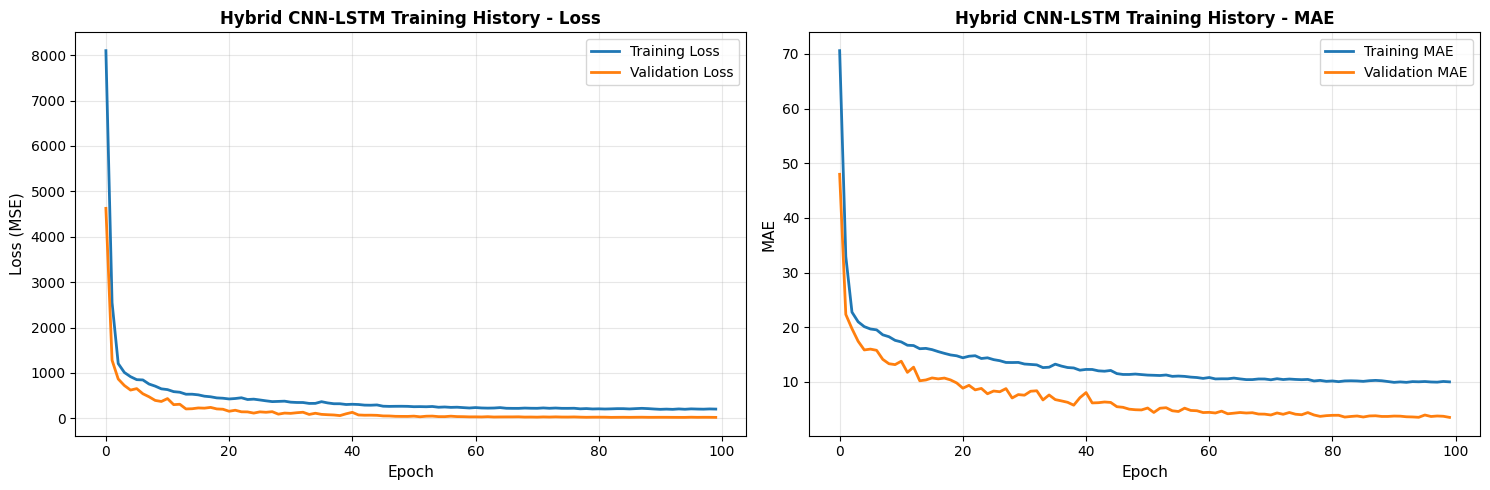

In [17]:
# Training History
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0].set_title('Hybrid CNN-LSTM Training History - Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history['train_mae'], label='Training MAE', linewidth=2)
axes[1].plot(history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('Hybrid CNN-LSTM Training History - MAE', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

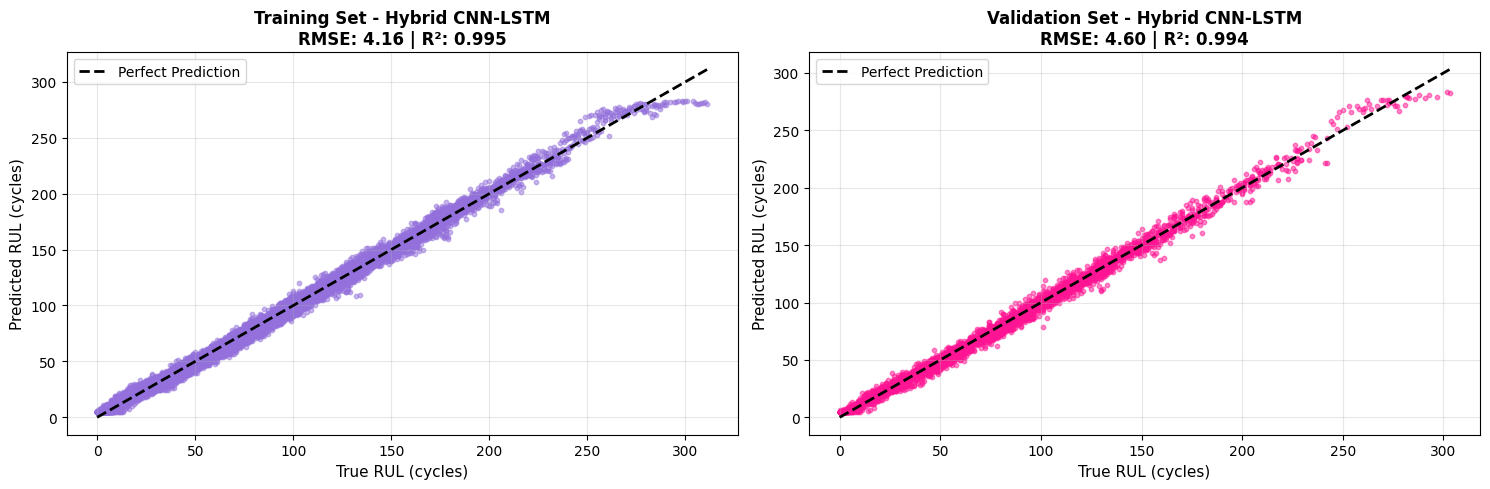

In [18]:
# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=10, color='mediumpurple')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
             'k--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('True RUL (cycles)', fontsize=11)
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=11)
axes[0].set_title(f'Training Set - Hybrid CNN-LSTM\nRMSE: {train_rmse:.2f} | R²: {train_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation
axes[1].scatter(y_val, y_val_pred, alpha=0.5, s=10, color='deeppink')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             'k--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('True RUL (cycles)', fontsize=11)
axes[1].set_ylabel('Predicted RUL (cycles)', fontsize=11)
axes[1].set_title(f'Validation Set - Hybrid CNN-LSTM\nRMSE: {val_rmse:.2f} | R²: {val_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()